Tutorial
================




Quickstart
-------------

This tutorial explains the three steps:

1. Build and store a large training dataset from a physics simulation. We will use a black body.
2. Load the training dataset
3. Train the emulator.
4. Diagnose the quality of the emulator
5. Use the emulator to predict.


In [1]:
import numpy as np
import astropy.units as u
import tqdm
import matplotlib.pyplot as plt

In [2]:
rng = np.random.default_rng(seed=42)

## 1. Building a training dataset

First, we use our real physics simulation to predict spectra.

These need to be stored, for which we use `specsimile.DatasetWriter`.


In [3]:
from specsimile.store import DatasetWriter


In this example, we sample black body temperatures and normalisation (area), a model already conveniently available in astropy.


In [4]:
from astropy.modeling.physical_models import BlackBody

In [5]:
def make_random_blackbody(rng):
    area = (rng.uniform(0, 1) * u.au)**2 * 4 * np.pi * u.sr
    distance = rng.uniform(0, 100) * u.kpc
    T = rng.uniform(5000, 10000) * u.K
    norm = area / distance**2
    spectrum = (BlackBody(T)(wave_grid) * norm).to(u.erg/u.s/u.Hz/u.cm**2).to(u.mJy)
    # store parameters in log, so the mapping is easier for the neural network
    logT_keV = np.log10(T.to_value(u.K))
    lognorm_sr = np.log10(norm.to_value(u.sr))
    return [logT_keV, lognorm_sr], spectrum


We want to build our emulator in the 500nm to 700nm range.


In [6]:
wave_grid = np.round(np.geomspace(500, 700, 40)) * u.nm
wave_grid

<Quantity [500., 504., 509., 513., 518., 522., 527., 531., 536., 540.,
           545., 550., 555., 559., 564., 569., 574., 579., 584., 589.,
           594., 599., 605., 610., 615., 620., 626., 631., 637., 642.,
           648., 653., 659., 665., 670., 676., 682., 688., 694., 700.] nm>

In [7]:
params, y = make_random_blackbody(rng)

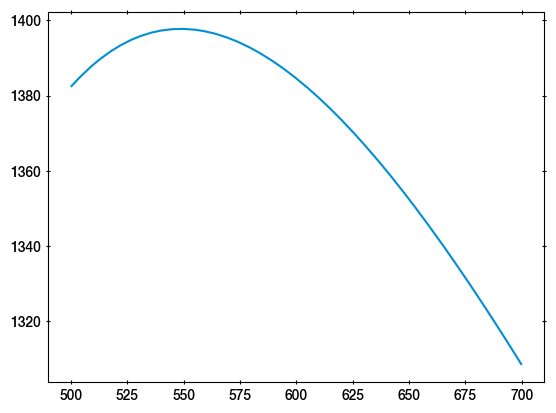

In [8]:
plt.plot(wave_grid, y)

In [9]:
N = 10000
writer = DatasetWriter(filename='bbody_data3.hdf5', N=N, x=wave_grid, y=y, xunit=wave_grid.unit, paramnames=["logT", "log_area"], params=params)

In [10]:
for i in tqdm.trange(10000):
    params, spectrum = make_random_blackbody(rng)
    writer.append(wave_grid, spectrum, params)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [04:28<00:00, 37.24it/s]


In [11]:
writer.close()

## 2. Load the training data

In [12]:
from specsimile.store import DatasetReader

In [13]:
ds = DatasetReader('bbody_data3.hdf5')

In [14]:
print(ds)

Dataset(filename=bbody_data3.hdf5,
xlabel=, x=500.0..700.0, xunit=nm,
ylabel=, y=9.829986266981564e-07..10194846724.34348, yunit=,
)


## 3. Train an emulator

First, we need to choose our approximating function. Here are the options currently implemented:

- A cut-off power law
- A log-quadratic function
- A smoothly bending powerlaw (SBPL) function **<-- we will use this one here**
- A dense neural network for predicting the flux at each x point

In [15]:
from specsimile.decoders import LogDenseDecoder, SBPLDecoder, CutoffPLDecoder, QuadraticDecoder

In [16]:
decoder = SBPLDecoder(
    x=wave_grid, # optional, will be overwritten during training
    x0=625, # choose where to normalise our approximating bending power law
    slope_scale=2.5, # allow slopes ranging from -2.5 to 2.5 (these are soft limits)
    logx_pad=1.0, # allow the break of the powerlaw to be 10x below or above the x/wavelength limits
    logwidth_lo=-1.0, # break width is at least 0.1 dex
    logwidth_hi=1.0, # break width is at most 10 dex
)

In [17]:
from specsimile import Emulator

In [18]:
emu = Emulator(
    'bbody_emulator.pt', # where to store the trained neural network
    decoder=decoder, # our parametric decoder
    shape=[32, 32, 32], # neural network architecture: number of neurons in each layer.
    dynamic_range=2.0, # the loss should only care about 2 dex from the peak
)

In [19]:
emu.fit(
    dataset=ds, # our training data
    epochs=200, # how many training epochs
    lr=1e-4, # learning rate
    batch_size=512,
)

emulator architecture: [P:2]-[MLP:32-32-32]->[latent:5]-SBPL-[y:40]
Epoch 1/200: RMS loss=0.856
Epoch 2/200: RMS loss=0.847
Epoch 3/200: RMS loss=0.838
Epoch 4/200: RMS loss=0.827
Epoch 5/200: RMS loss=0.814
Epoch 6/200: RMS loss=0.799
Epoch 7/200: RMS loss=0.781
Epoch 8/200: RMS loss=0.760
Epoch 9/200: RMS loss=0.735
Epoch 10/200: RMS loss=0.705
Epoch 11/200: RMS loss=0.670
Epoch 12/200: RMS loss=0.630
Epoch 13/200: RMS loss=0.581
Epoch 14/200: RMS loss=0.527
Epoch 15/200: RMS loss=0.464
Epoch 16/200: RMS loss=0.395
Epoch 17/200: RMS loss=0.322
Epoch 18/200: RMS loss=0.250
Epoch 19/200: RMS loss=0.187
Epoch 20/200: RMS loss=0.155
Epoch 21/200: RMS loss=0.135
Epoch 22/200: RMS loss=0.118
Epoch 23/200: RMS loss=0.105
Epoch 24/200: RMS loss=0.093
Epoch 25/200: RMS loss=0.083
Epoch 26/200: RMS loss=0.075
Epoch 27/200: RMS loss=0.068
Epoch 28/200: RMS loss=0.061
Epoch 29/200: RMS loss=0.056
Epoch 30/200: RMS loss=0.051
Epoch 31/200: RMS loss=0.047
Epoch 32/200: RMS loss=0.044
Epoch 33/200:

'bbody_emulator.pt'

## 4. Diagnose approximation quality 

In [20]:
from specsimile import plot as emuplot

In [21]:
xlabel = f"{ds.xlabel} [{ds.xunit}]" if ds.xunit else ds.xlabel
ylabel = f"{ds.ylabel} [{ds.yunit}]" if ds.yunit else ds.ylabel

ev = emu.evaluate(ds, nmax=5000, seed=123, return_decoded_params=True)

### Histogram of root mean square error (in log-axes)

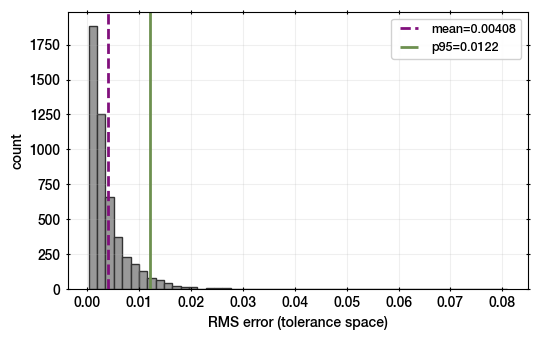

In [22]:
# error histogram
fig, ax = emuplot.plot_error_hist(ev)

The 95% worst error is:

In [23]:
print(f"p95 err = {np.percentile(ev['err'], 95):.6g}")

p95 err = 0.0121556


### Example data and learned approximations: typical and worst

The top two rows are the first few in the dataset.
The bottom two rows are the worst fits.

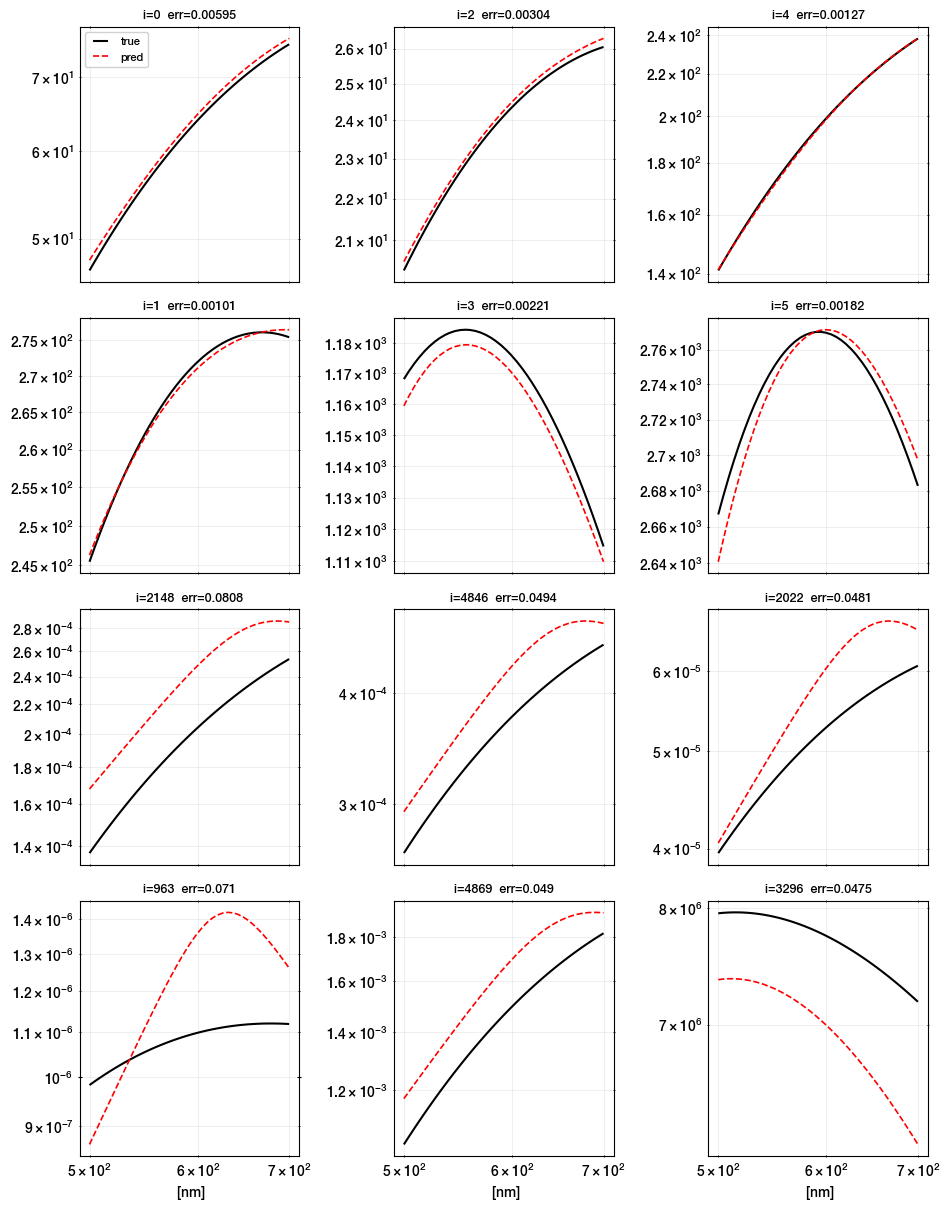

In [24]:
fig, axes = emuplot.plot_fit_examples(ev, n_first=6, n_worst=6, yscale="log")

[ax.set_ylabel(ylabel) for ax in axes[:, 0]]
[ax.set_xlabel(xlabel) for ax in axes[-1, :]];

### Diagnose for which input parameters the fit is good:

/mnt/data/daten/PostDoc2/home/Downloads/quasartomography/specsimile/specsimile/plot.py:127: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


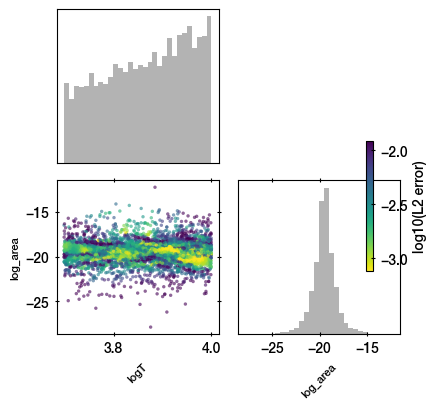

In [25]:
fig, axes = emuplot.plot_param_corner_scatter(ev, param_names=ds.paramnames)

You can use the plot above to change your sampling, for example if the training sample contains undesirable parameter combinations.

### Diagnose the approximating function parameter range vs fit quality

/mnt/data/daten/PostDoc2/home/Downloads/quasartomography/specsimile/specsimile/plot.py:179: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


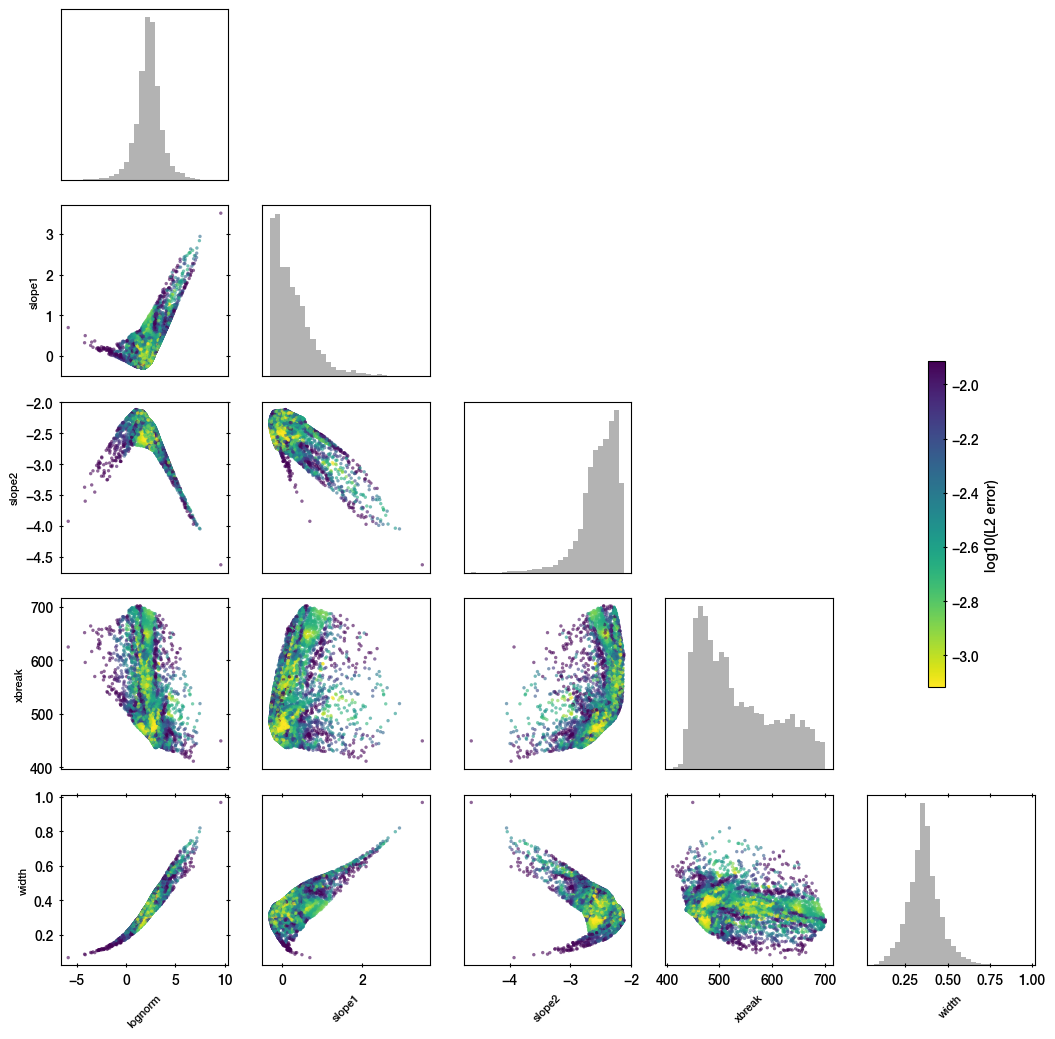

In [26]:
fig, axes = emuplot.plot_decoder_param_corner_scatter(ev, param_names=decoder.paramnames)

You can use the above to widen the priors on slopes and break wavelength.

## Predict new data

Let's evaluate and predict on a much higher spectral resolution grid.

In [27]:
x = np.geomspace(400, 800, 1000) * u.nm

Choose some parameters where to evaluate

In [28]:
params

[np.float64(3.996664739005793), np.float64(-19.697265398586186)]

In [29]:
T = 9000 * u.K
logT = np.log10(T.to_value(u.K))
log_area = -19.7

In [30]:
params_predict = emu.transform(params=np.array([logT, log_area]), x=x, return_latent_params=True)

In [31]:
y = emu.transform(params=np.array([logT, log_area]), x=x, return_latent_params=False)

In [32]:
y_true = (BlackBody(T)(x) * 10**log_area * u.sr).to(u.erg/u.s/u.Hz/u.cm**2).to(u.mJy)

In [33]:
wave_grid.value

array([500., 504., 509., 513., 518., 522., 527., 531., 536., 540., 545.,
       550., 555., 559., 564., 569., 574., 579., 584., 589., 594., 599.,
       605., 610., 615., 620., 626., 631., 637., 642., 648., 653., 659.,
       665., 670., 676., 682., 688., 694., 700.])

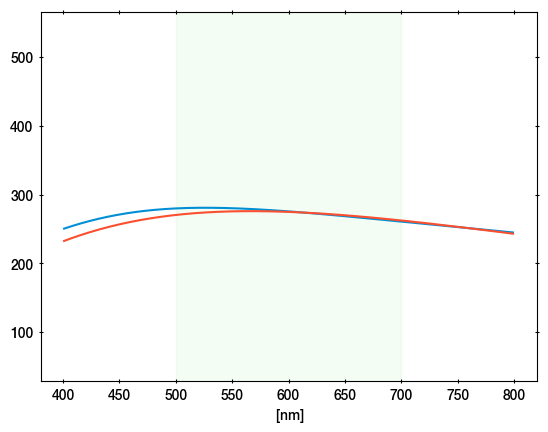

In [34]:
plt.plot(x, y)
plt.plot(x, y_true)
ylo, yhi = plt.ylim()
plt.fill_between(wave_grid.value, wave_grid.value*0, wave_grid.value*0 + yhi*2, color='lightgreen', alpha=0.1)
#plt.yscale('log')
plt.ylim(min(yhi / 10, ylo), yhi*2)
plt.xlabel(xlabel)
plt.ylabel(ylabel);

## Takeaways

That's it! Now you learned how to use specsimile to 
1. approximate spectra,
2. diagnose the approximation quality
3. use the parametric approximation to predict on other data